# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# cargar archivos
df_plans = pd.read_csv('/datasets/plans.csv')
df_users = pd.read_csv('/datasets/users_latam.csv')
df_usage = pd.read_csv('/datasets/usage.csv')

In [5]:
df_plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [6]:
df_users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [7]:
df_usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [8]:
# revisar el número de filas y columnas de cada dataset
print("plans", df_plans.shape)
print("users", df_users.shape)
print("usage", df_usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [9]:
df_plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [10]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [11]:
df_usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [12]:
# cantidad de nulos para users
print(df_users.isna().sum())
print(df_users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [13]:
print(df_usage.isna().sum())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [14]:
df_users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id`tiene un minimo de 10000, lo que significa que los ids empiezan an ese numero
- La columna `age` tiene algunos problemas, ya que nos muestra como minimo un numero negativo, asi que no podriamos confiar mucho en sus valores restantes. 

In [15]:
df_usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas tiene mucha diferencia en datos, ya que los manda de alguna manera mal. Podemos ver valores muy extremos. Por ejemplo los minimos, ahi es donde se ven mas diferencias, ya que al ver los porcentajes, podemos notar que en uer_id es un rango muy parecido, sin embargo con id podemos ver una fuerte variacion. 

In [16]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(df_users['city'].value_counts())
print(df_users['plan'].value_counts())    


Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` tiene algunos datos erroneos al tener signos de interrogacion 96 veces. 
- La columna `plan` tiene tan solo el plan basico y premium, al parecer por cada premium casi son dos bsaicos

In [17]:
# explorar columna categórica de usage
df_usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` tiene todo los tipos de textos, los que dicen text y los que dicen call.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [18]:



# Convertir a fecha la columna `reg_date` de users
df_users["reg_date"] = pd.to_datetime(df_users["reg_date"], errors="coerce")





In [19]:
# Convertir a fecha la columna `date` de usage
df_usage["date"] = pd.to_datetime(df_usage["date"], errors = "coerce")

In [20]:
df_usage["date"].dt.year.value_counts()


2024.0    39950
Name: date, dtype: int64

En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

In [21]:
df_users["reg_date"].dt.year.value_counts()


2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [22]:
# Reemplazar -999 por la mediana de age
age_mediana = df_users["age"].median()
df_users["age"] = df_users['age'].replace(-999,age_mediana)

# Verificar cambios
df_users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [23]:
print(df_users["reg_date"].dtype)

datetime64[ns]


In [24]:
# Reemplazar ? por NA en city
df_users["city"] = df_users["city"].replace("?","NA")

# Verificar cambios
df_users["city"].describe()

count       3531
unique         7
top       Bogotá
freq         808
Name: city, dtype: object

In [25]:
from datetime import date

In [26]:
fecha_hoy = date.today()

In [27]:

# Marcar fechas futuras como NA para reg_date
fecha_hoy = pd.Timestamp.now().normalize()  # Convierte a pandas Timestamp
fechas_futuras = df_users["reg_date"] > fecha_hoy
df_users.loc[fechas_futuras, "reg_date"] = pd.NaT



# Verificar cambios
df_users["reg_date"].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [28]:

# Verificación MAR en usage (Missing At Random) para duration
df_usage["duration_missing"] = df_usage["duration"].isna()
df_usage["duration"].isna().groupby(df_usage["type"]).mean()



type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [32]:
# Verificación MAR en usage (Missing At Random) para length
df_usage["duration_missing"] = df_usage["length"].isna()
df_usage["length"].isna().groupby(df_usage["type"]).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

ambos estan correctos ya que tienen las duraciones que podriamo estimar en lo que estamos tratando de analizar. Por ejempplo que las llamadas tienen datos en durationm, osea que os datos si fueron llenadfos.
mismo escneario en la length, ya que no tiene duracion. 

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [64]:


# Columnas auxiliares
df_usage["is_text"] = (df_usage["type"] == "text").astype(int) #conocer el total de mensajes
df_usage["is_call"] = (df_usage["type"] == "call").astype(int) #conocer el total de llamadas



# Agrupar información por usuario
usage_agg = df_usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index().rename(columns={
    "is_text": "cantidad_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)


,user_id,cantidad_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [70]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = df_users.merge(usage_agg, on = "user_id", how = "left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cantidad_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [72]:
# Resumen estadístico de las columnas numéricas
user_profile[["age", "cantidad_mensajes","cant_llamadas","cant_minutos_llamada" ]].describe()

,age,cantidad_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [78]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize = True)*100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

In [79]:
print("DataFrames disponibles:")
print("- users:", 'df_users' in locals())
print("- usage:", 'df_usage' in locals()) 
print("- plans:", 'df_plans' in locals())

DataFrames disponibles:
- users: True
- usage: True
- plans: True


In [80]:
df_usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                40000 non-null  int64         
 1   user_id           40000 non-null  int64         
 2   type              40000 non-null  object        
 3   date              39950 non-null  datetime64[ns]
 4   duration          17924 non-null  float64       
 5   length            22104 non-null  float64       
 6   duration_missing  40000 non-null  bool          
 7   is_text           40000 non-null  int64         
 8   is_call           40000 non-null  int64         
dtypes: bool(1), datetime64[ns](1), float64(2), int64(4), object(1)
memory usage: 2.5+ MB


In [81]:
df_usage["type"].value_counts()

text    22092
call    17908
Name: type, dtype: int64

In [82]:
cant_mensajes = df_usage[df_usage["type"] == "text"].groupby("user_id").size()

In [83]:
cant_llamadas = df_usage[df_usage["type"] == "call"].groupby("user_id").size()


In [84]:
total_minutos_llamada = df_usage[df_usage["type"] == "call"].groupby("user_id")["duration"].sum()


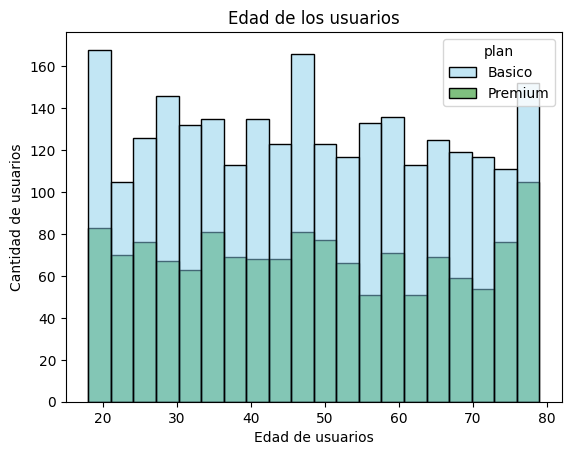

In [85]:

# Histograma para visualizar la edad (cantidad de mensajes)
sns.histplot(data=df_users, x="age", hue = "plan", palette=["skyblue","green"], bins = 20)
plt.title("Edad de los usuarios")
plt.xlabel("Edad de usuarios")
plt.ylabel("Cantidad de usuarios")
plt.show()


💡Insights: 
Esta muy bien distribuido, ya que la informacion muestra quue nuestras edades ma simportantes son, los 20s y los altos 40s. Sin embargo notamos como tambien arriba de 70 años es una edad importante ya que muestra que tiene muchos premium.

In [86]:

df_mensajes = cant_mensajes.reset_index()
df_mensajes.columns = ['user_id', 'cantidad_mensajes']


In [87]:
df_mensajes = cant_mensajes.reset_index()
df_mensajes.columns = ['user_id', 'cant_mensajes']

In [88]:
df_analisis = df_mensajes.merge(df_users[['user_id', 'plan']], on='user_id', how='left')

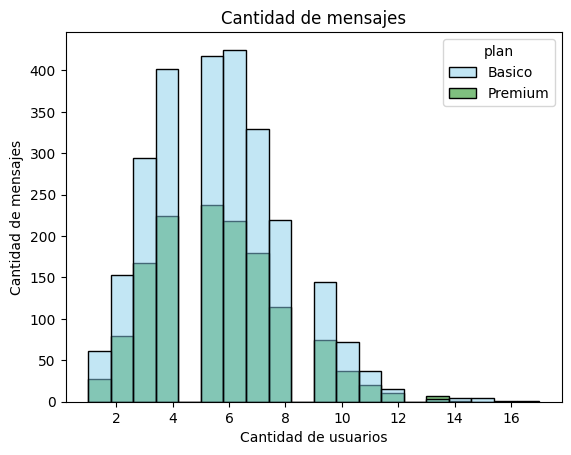

In [89]:



sns.histplot(data=df_analisis,x="cant_mensajes",  hue = "plan", palette=["skyblue","green"] , bins=20)
plt.title("Cantidad de mensajes")
plt.xlabel("Cantidad de usuarios")
plt.ylabel("Cantidad de mensajes")
plt.show()



💡Insights: 
-Sesgo fuerte a al derecha, por otro lado vemos que un poco mas de la mitad de todas las variantes o clientes, tienen mas del 50% de plan premium.

In [90]:

df_llamadas = cant_llamadas.reset_index()
df_llamadas.columns = ['user_id', 'cant_llamadas']


In [91]:
df_analisisll.head()

,user_id,cant_llamadas,plan
0,10000,3,Basico
1,10001,10,Basico
2,10002,2,Basico
3,10003,3,Premium
4,10004,3,Basico


In [92]:
df_analisisll = df_llamadas.merge(df_users[['user_id', 'plan']], on='user_id', how='left')

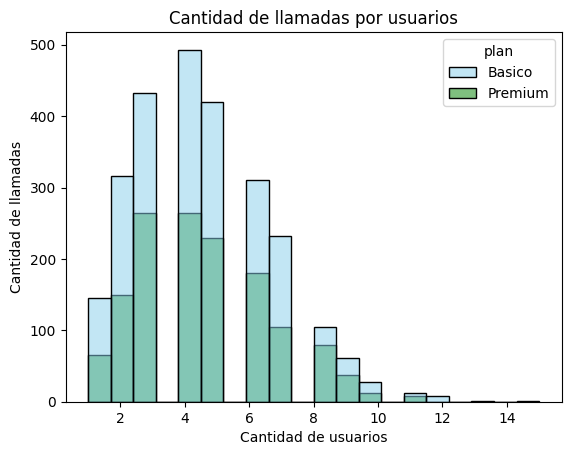

In [93]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=df_analisisll, x="cant_llamadas", hue = "plan", palette=["skyblue","green"], bins=20)
plt.title("Cantidad de llamadas por usuarios")
plt.xlabel("Cantidad de usuarios")
plt.ylabel("Cantidad de llamadas")
plt.show()



💡Insights: 
La mayoria de los usuarios tiene pocos mensajes, no se centrifica tanto en el total de los mensajes totales. de igual forma tiene un sesgo fuerte a la derecha.

In [94]:
df_total_minutos_llamada = total_minutos_llamada.reset_index()
df_total_minutos_llamada.columns = ['user_id', 'total_minutos_llamada']

In [95]:
df_analisislla = df_total_minutos_llamada.merge(df_users[['user_id', 'plan']], on='user_id', how='left')

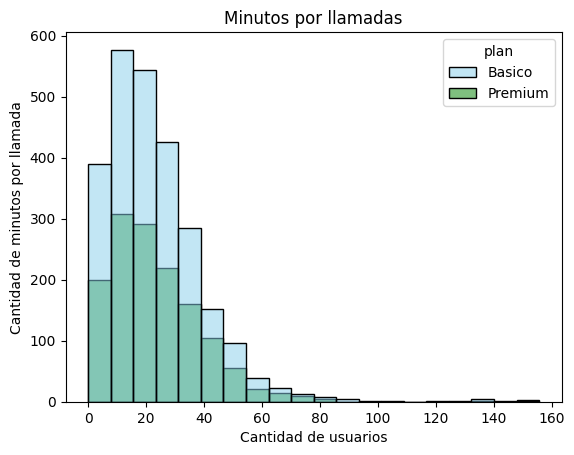

In [96]:

# Histograma para visualizar la cant_minutos_llamada

sns.histplot(data=df_analisislla, x="total_minutos_llamada", hue = "plan", palette=["skyblue","green"], bins=20)
plt.title("Minutos por llamadas")
plt.xlabel("Cantidad de usuarios")
plt.ylabel("Cantidad de minutos por llamada")
plt.show()


💡Insights: 
-Se ve un sesgo fuerte a la derecha, ya que nunca nadie puede al parecer tener tantos minutos por llamadas. 

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

In [97]:

# Crear DataFrames con solo las columnas que necesitas
df_age = df_users[['user_id', 'age']]
df_minutos = df_analisislla[['user_id', 'total_minutos_llamada']]
df_llamadas = df_analisisll[['user_id', 'cant_llamadas']]
df_mensajes = df_analisis[['user_id', 'cant_mensajes']]

In [98]:

df_nuevo = df_age.copy()


# Hacer merge con cada DataFrame uno por uno

df_nuevo = pd.merge(df_nuevo, df_minutos, on='user_id', how='inner')
df_nuevo = pd.merge(df_nuevo, df_llamadas, on='user_id', how='inner')
df_nuevo = pd.merge(df_nuevo, df_mensajes, on='user_id', how='inner')

In [99]:
df_age_plan = df_users[['user_id', 'age', 'plan']]
df_minutos = df_analisislla[['user_id', 'total_minutos_llamada']]
df_llamadas = df_analisisll[['user_id', 'cant_llamadas']]
df_mensajes = df_analisis[['user_id', 'cant_mensajes']]

In [100]:
df_nuevo = df_age_plan.copy()

# Hacer merge con cada DataFrame uno por uno
df_nuevo = pd.merge(df_nuevo, df_minutos, on='user_id', how='inner')
df_nuevo = pd.merge(df_nuevo, df_llamadas, on='user_id', how='inner')
df_nuevo = pd.merge(df_nuevo, df_mensajes, on='user_id', how='inner')

# Verificar el resultado
print("Forma del DataFrame final:", df_nuevo.shape)
print("Columnas:", df_nuevo.columns.tolist())
df_nuevo.head()

Forma del DataFrame final: (3940, 6)
Columnas: ['user_id', 'age', 'plan', 'total_minutos_llamada', 'cant_llamadas', 'cant_mensajes']


,user_id,age,plan,total_minutos_llamada,cant_llamadas,cant_mensajes
0,10000,38.0,Basico,23.70,3,7
1,10001,53.0,Basico,33.18,10,5
2,10002,57.0,Basico,10.74,2,5
3,10003,69.0,Premium,8.99,3,11
4,10004,63.0,Basico,8.01,3,4


In [101]:
print(df_nuevo.columns.tolist())

['user_id', 'age', 'plan', 'total_minutos_llamada', 'cant_llamadas', 'cant_mensajes']


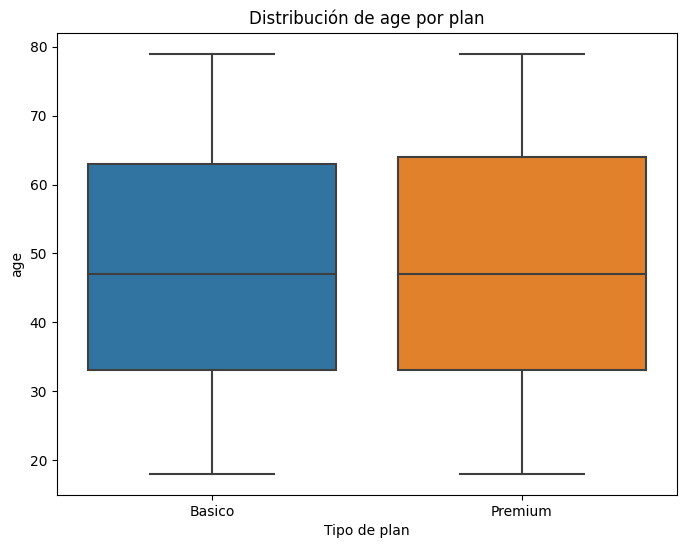

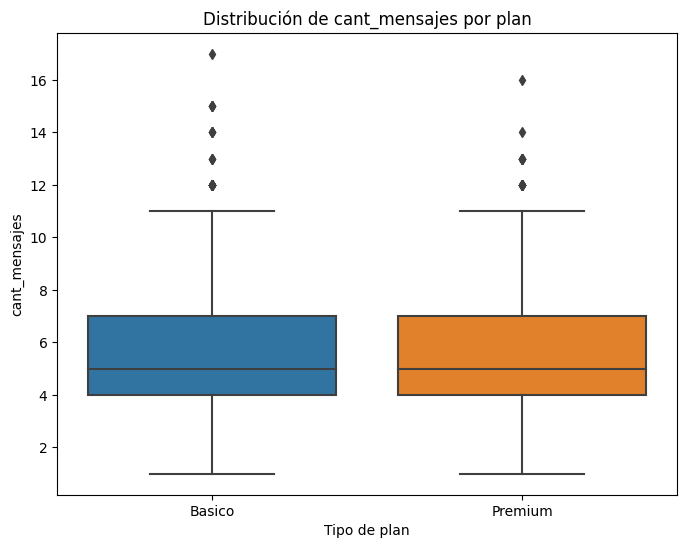

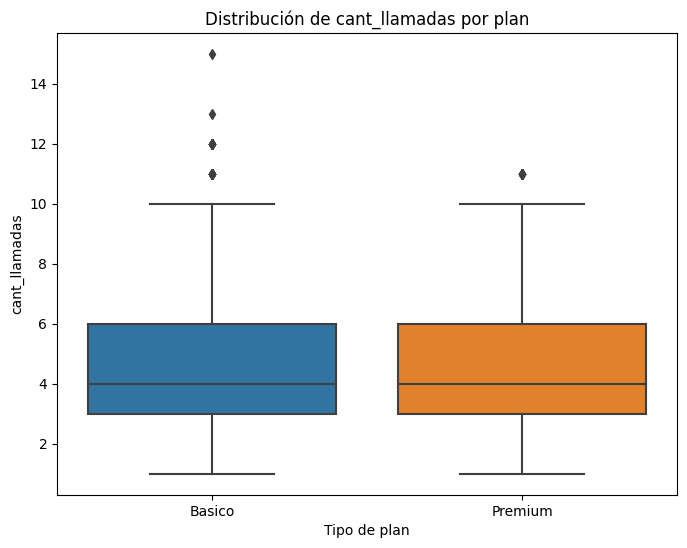

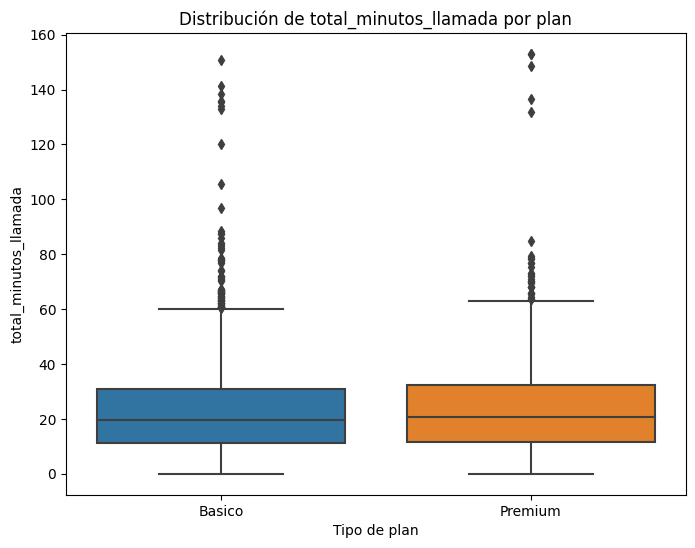

In [102]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'total_minutos_llamada']

for columna in columnas_numericas:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df_nuevo, x="plan", y=columna)
    plt.title(f"Distribución de {columna} por plan")
    plt.xlabel("Tipo de plan")
    plt.ylabel(columna)
    plt.show()
    

💡Insights: 
- Age: ...(presenta o no outliers)
- cant_mensajes: ...
- cant_llamadas: ...
- cant_minutos_llamada: ...

In [103]:
# Lista de columnas numéricas para analizar
columnas_numericas = ['age', 'total_minutos_llamada', 'cant_llamadas', 'cant_mensajes']

# Diccionario para almacenar los límites
columnas_limites = {}

# Calcular límites para cada columna
for columna in columnas_numericas:
    # Calcular cuartiles
    Q1 = df_nuevo[columna].quantile(0.25)
    Q3 = df_nuevo[columna].quantile(0.75)
    
    # Calcular IQR
    IQR = Q3 - Q1
    
    # Calcular límites
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Guardar en el diccionario
    columnas_limites[columna] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior
    }
    
    print(f"Columna: {columna}")
    print(f"  Q1: {Q1:.2f}")
    print(f"  Q3: {Q3:.2f}")
    print(f"  IQR: {IQR:.2f}")
    print(f"  Límite inferior: {limite_inferior:.2f}")
    print(f"  Límite superior: {limite_superior:.2f}")
    print()


Columna: age
  Q1: 33.00
  Q3: 63.00
  IQR: 30.00
  Límite inferior: -12.00
  Límite superior: 108.00

Columna: total_minutos_llamada
  Q1: 11.34
  Q3: 31.29
  IQR: 19.95
  Límite inferior: -18.59
  Límite superior: 61.22

Columna: cant_llamadas
  Q1: 3.00
  Q3: 6.00
  IQR: 3.00
  Límite inferior: -1.50
  Límite superior: 10.50

Columna: cant_mensajes
  Q1: 4.00
  Q3: 7.00
  IQR: 3.00
  Límite inferior: -0.50
  Límite superior: 11.50



In [104]:
user_profile = df_nuevo.copy()

# Verificar que tiene las columnas correctas
print("Columnas en user_profile:")
print(user_profile.columns.tolist())
print(f"Forma del DataFrame: {user_profile.shape}")

Columnas en user_profile:
['user_id', 'age', 'plan', 'total_minutos_llamada', 'cant_llamadas', 'cant_mensajes']
Forma del DataFrame: (3940, 6)


In [105]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,total_minutos_llamada,cant_llamadas,cant_mensajes
count,3940.000000,3940.000000,3940.000000,3940.000000
mean,48.106345,23.006325,4.518020,5.550508
std,17.693653,16.370103,2.102581,2.334165
min,18.000000,0.020000,1.000000,1.000000
25%,33.000000,11.337500,3.000000,4.000000
50%,47.000000,19.835000,4.000000,5.000000
75%,63.000000,31.292500,6.000000,7.000000
max,79.000000,153.060000,15.000000,17.000000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [111]:
# Crear columna grupo_uso
import numpy as np

user_profile["grupo_uso"] = np.where(
    (user_profile["cant_llamadas"] < 5) & (user_profile["cant_mensajes"] < 5), 
    "Bajo uso",
    np.where(
        (user_profile["cant_llamadas"] < 10) & (user_profile["cant_mensajes"] < 10), 
        "Uso medio", 
        "Alto uso"
    )
)

In [112]:
# verificar cambios
user_profile.head()

,user_id,age,plan,total_minutos_llamada,cant_llamadas,cant_mensajes,grupo_uso
0,10000,38.0,Basico,23.70,3,7,Uso medio
1,10001,53.0,Basico,33.18,10,5,Alto uso
2,10002,57.0,Basico,10.74,2,5,Uso medio
3,10003,69.0,Premium,8.99,3,11,Alto uso
4,10004,63.0,Basico,8.01,3,4,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [113]:
# Crear columna grupo_edad
import numpy as np

user_profile["grupo_edad"] = np.where(
    (user_profile["age"] < 30), 
    "Joven",
    np.where(
        (user_profile["age"] < 60), 
        "Adulto", 
        "Adulto Mayor"
    )
)

In [114]:
# verificar cambios
user_profile.head()

,user_id,age,plan,total_minutos_llamada,cant_llamadas,cant_mensajes,grupo_uso,grupo_edad
0,10000,38.0,Basico,23.70,3,7,Uso medio,Adulto
1,10001,53.0,Basico,33.18,10,5,Alto uso,Adulto
2,10002,57.0,Basico,10.74,2,5,Uso medio,Adulto
3,10003,69.0,Premium,8.99,3,11,Alto uso,Adulto Mayor
4,10004,63.0,Basico,8.01,3,4,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

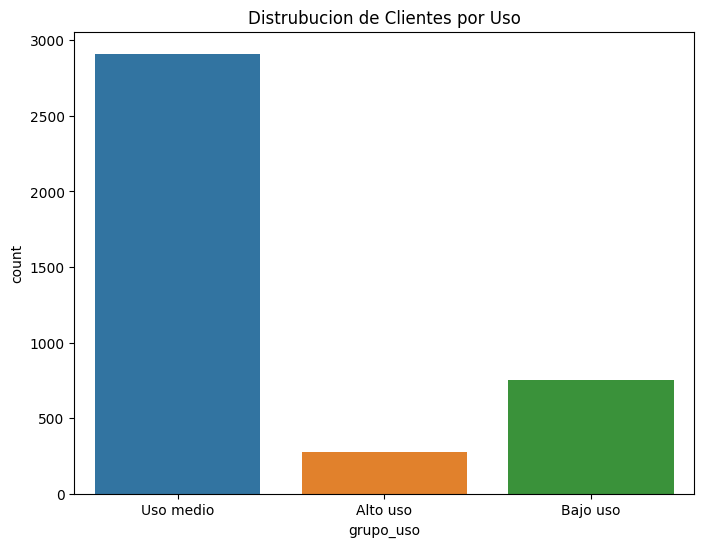

In [115]:
# Visualización de los segmentos por uso
plt.figure(figsize= (8,6))
sns.countplot(data=user_profile, x= "grupo_uso")
plt.title("Distrubucion de Clientes por Uso")
plt.show()

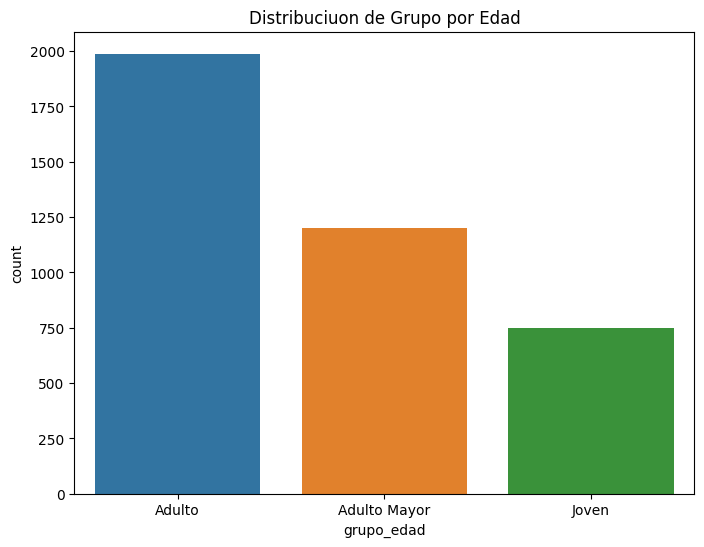

In [116]:
# Visualización de los segmentos por edad
plt.figure (figsize = (8,6))
sns.countplot(data = user_profile, x="grupo_edad")
plt. title("Distribuciuon de Grupo por Edad")
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

8.1 Análisis Ejecutivo
Problemas detectados en los datos
Durante la exploración y limpieza de los datasets se detectaron varios problemas de calidad de datos que podían afectar el análisis:
1. Valores sentinels en edad
•	En la columna age existía el valor -999, que representa un valor inválido.
•	Este valor distorsionaba las estadísticas (por ejemplo, la media y desviación estándar).
•	Se corrigió reemplazándolo con la mediana de la edad (47 años) para mantener la distribución realista de los usuarios.
2. Valores inválidos en la ciudad
•	La columna city contenía el valor "?" en 96 registros, lo que representa aproximadamente 2.4% del dataset.
•	Estos valores fueron reemplazados por NA, ya que no es posible inferir correctamente la ciudad.
3. Valores faltantes en churn_date
•	Aproximadamente 88% de los registros estaban vacíos en esta columna.
•	Esto es esperable, ya que la mayoría de los usuarios no ha cancelado el servicio.
4. Fechas fuera de rango
•	En la columna reg_date se detectaron 40 registros con fechas en el año 2026, cuando el dataset sólo contiene datos hasta 2024.
•	Estas fechas fueron marcadas como NaT (nulas) para evitar errores en el análisis temporal.
5. Valores nulos en usage
•	Las columnas duration y length tenían muchos valores nulos.
•	Sin embargo, se confirmó que estos siguen un patrón MAR (Missing At Random):
•	Las llamadas tienen valores en duration
•	Los mensajes tienen valores en length
Esto indica que los datos faltantes son esperados según el tipo de uso, por lo que no fue necesario imputarlos.
________________________________________
Segmentos por Edad
Los usuarios fueron clasificados en tres grupos:
Segmento	Condición
Joven	< 30 años
Adulto	30 - 59 años
Adulto Mayor	≥ 60 años
Se observó que:
•	La mayoría de los clientes pertenece al segmento Adulto.
•	Existe también una presencia importante de Adultos Mayores, especialmente dentro del plan Premium.
•	Los usuarios jóvenes representan una menor proporción del total.
Esto sugiere que el servicio es utilizado principalmente por clientes de mediana edad y mayores, lo que puede influir en la forma en que utilizan llamadas y mensajes.
________________________________________
Segmentos por Nivel de Uso
Los clientes fueron segmentados según su comportamiento de uso:
Segmento	Condición
Bajo uso	<5 llamadas y <5 mensajes
Uso medio	<10 llamadas y <10 mensajes
Alto uso	resto
Se identificaron tres comportamientos claros:
Bajo uso
Usuarios que utilizan el servicio de manera ocasional.
Posibles características:
•	Consumo limitado de minutos y mensajes
•	Probablemente utilizan otras plataformas de comunicación (apps)
Uso medio
Representa el grupo más común.
Características:
•	Uso regular de llamadas y mensajes
•	Consumo moderado de servicios
•	Representa el perfil promedio del cliente
Alto uso
Usuarios con mayor actividad en llamadas y mensajes.
Características:
•	Alta frecuencia de llamadas
•	Mayor probabilidad de exceder los límites del plan
•	Generan mayor ingreso potencial para la empresa
________________________________________
Patrones de uso y outliers
El análisis de outliers mostró:
Edad
•	No se identificaron outliers relevantes.
•	Los valores se mantienen dentro de un rango lógico (18 a 79 años).
Cantidad de mensajes y llamadas
•	Se detectaron algunos usuarios con uso alto.
•	Sin embargo, estos valores representan usuarios intensivos, no errores de datos.
Minutos de llamada
•	Algunos usuarios alcanzan más de 150 minutos, lo que supera el rango típico.
•	Esto indica la presencia de usuarios heavy users.
Estos outliers no fueron eliminados, ya que representan comportamientos reales de clientes valiosos.
________________________________________
 Segmentos más valiosos para ConnectaTel
Los segmentos con mayor valor potencial son:
Usuarios Premium
•	Pagan una tarifa mensual mayor
•	Tienen mayor uso promedio
Usuarios de Alto Uso
•	Generan mayor consumo del servicio
•	Mayor probabilidad de pagar extras
Adultos y Adultos Mayores
•	Muestran mayor estabilidad en el uso
•	Probablemente tengan menor churn
Estos grupos representan los clientes con mayor valor para el negocio.
________________________________________
Recomendaciones estratégicas
1. Crear un plan para heavy users
El análisis muestra usuarios con alto consumo de minutos y mensajes.
Se podría lanzar un plan:
Plan Ultra / Pro
•	Minutos ilimitados
•	Mayor cantidad de datos
•	Precio mayor
Esto permitiría capturar más ingresos de los usuarios intensivos.
________________________________________
2. Crear un plan económico para bajo uso
Los usuarios de bajo uso podrían beneficiarse de un plan más económico:
Plan Lite
•	Menos minutos
•	Menos mensajes
•	Precio reducido
Esto podría ayudar a reducir churn en clientes que usan poco el servicio.
________________________________________
3. Personalizar estrategias por edad
Dado que la mayoría de usuarios son adultos:
•	Ofrecer beneficios de fidelización
•	Programas de permanencia
•	Promociones para planes Premium
________________________________________
4. Monitorear el comportamiento de uso
El análisis de uso puede utilizarse para:
•	Detectar clientes que están cerca de exceder su plan
•	Ofrecer upgrades automáticos
•	Implementar recomendaciones de plan personalizadas
________________________________________
Conclusión
El análisis permitió identificar patrones claros de uso, detectar problemas de calidad de datos y segmentar a los clientes según su comportamiento.
Estos insights pueden ayudar a ConnectaTel a optimizar su oferta de planes, mejorar la retención de clientes y aumentar los ingresos mediante estrategias de segmentación más precisas.


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- abc
- abc


🔍 **Segmentos por Edad**
- abc
- abc 


📊 **Segmentos por Nivel de Uso**
- abc
- abc


➡️ Esto sugiere que ...


💡 **Recomendaciones**
- abc
- abc 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`